In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import math

In [2]:
img_plate = cv2.imread('DATA/car_plate.jpg')
rgb_plate = cv2.cvtColor(img_plate, cv2.COLOR_BGR2RGB)

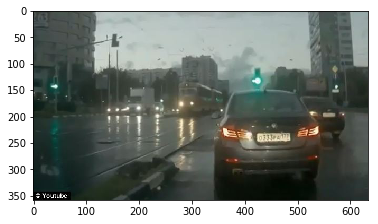

In [3]:
plt.imshow(rgb_plate)

In [4]:
plate_cascade = cv2.CascadeClassifier("DATA/haarcascades/haarcascade_russian_plate_number.xml")

In [13]:
def detect_plate(img):
    plate_img = img.copy()
    blurred_img = img.copy()
    
    plate_rect = plate_cascade.detectMultiScale(plate_img, scaleFactor=1.2, minNeighbors=3)
    
    for (x,y,w,h) in plate_rect:
        cv2.rectangle(plate_img, (x, y), (x+w, y+h), (0,255,255), 3)
        
        roi = blurred_img[y:y+h, x:x+w]
        blurred_roi = cv2.medianBlur(roi, 7)
        
        blurred_img[y:y+h, x:x+w] = blurred_roi
    
    return plate_img, blurred_img

In [14]:
rect, blurred = detect_plate(img_plate)

In [15]:
rgb_rect = cv2.cvtColor(rect, cv2.COLOR_BGR2RGB)
rgb_blurred = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)

In [47]:
def show_imgs(**images):

    if not images:
        raise ValueError("At least one image must be provided.")
    
#     titles = list(images.keys())
    titles = [k.replace('_', ' ') for k in images.keys()]
    img_list = list(images.values())
    num_images = len(img_list)
    
    max_cols = 2
    rows = math.ceil(num_images / max_cols)
    cols = min(num_images, max_cols)

    fig, axes = plt.subplots(rows, cols, figsize=(10 * cols, 6 * rows))

    # Flatten axes for uniform access
    if rows == 1:
        axes = [axes] if num_images == 1 else axes
    else:
        axes = axes.flatten()

    for i in range(num_images):
        axes[i].imshow(img_list[i])
        axes[i].set_title(titles[i])
        
    for i in range(len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


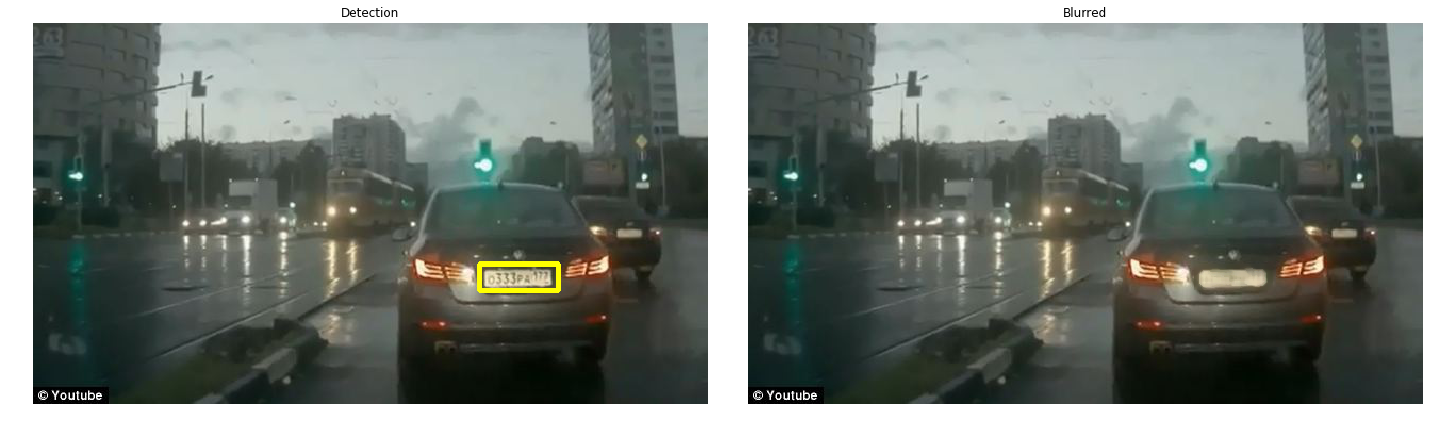

In [51]:
show_imgs(Detection = rgb_rect, Blurred = rgb_blurred)